# Notebook 3: Identificerbarhed og inferens i to-ø modellen

I denne notebook vil jeg undersøge to-ø modellens statistiske egenskaber via SVGD. Jeg fokuserer på tre centrale problemstillinger:

1. **Identificerbarhed**: Er det muligt at estimere coalescent- og migrationsrate separat eller er de sammenblandede?
2. **Method of Moments vs. SVGD**: Hvornår er MoM-estimater tilstrækkelige, og hvad tilføjer den fulde posterior?
3. **Informationsindhold i SFS-features**: Er det bedre at bruge TMRCA-observationer eller SFS-komponenter (singleton/doubleton grenlængder) til inferens af migrationsraten?

**To-ø modellen:** To populationer, hver med coalescentrate $\theta_0 = \frac{1}{N}$. Linjer migrerer symmetrisk med rate $\theta_1$. Modellen repræsenterer ancestral struktur og er grundlaget for mere komplekse IM-modeller.

In [1]:
# Importer de nødvendige pakker 
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

from phasic import (
    Graph, with_ipv,
    GaussPrior, HalfCauchyPrior, DataPrior,
    Adam, ExpStepSize, ExpRegularization,
    StateIndexer, Property,
    clear_caches, dense_to_sparse,
)  
import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
%config InlineBackend.figure_format = 'svg'

np.random.seed(42)
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (9, 4)

clear_caches()

  Removed 54 file(s), preserved directory structure


In [2]:
import vscodenb
vscodenb.is_vscode_dark_theme = lambda: (False, 'white')

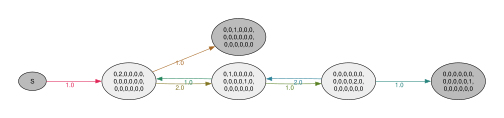

In [3]:
#| label: fig-two-island-graph
#| fig-cap: 'Tilstandsrum for to-ø modellen med $n=2$ linjer. Tilstandsvektoren $(s_1, s_2, \text{pop})$ tracker om de to linjer befinder sig i population $1$, population $2$ eller er delt. Pile angiver mulige overgange: koalescentovergange (blå) sker inden for samme population; migrationsovergange (rød) sender en linje fra én population til den anden. Absorptionstilstanden MRCA nås når begge linjer er i samme population og koalescerer.'
#| fig-width: 5
#| fig-height: 3

# To-ø modellen
nr_samples = 2

indexer = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples),
        Property('pop2', min_value=0, max_value=nr_samples),
        Property('in_pop', min_value=1, max_value=2),
    ]
)

initial = [0] * indexer.state_length
initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

@with_ipv(initial)
def two_island(state):
    transitions = []
    if state[indexer.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)
        for j in range(i, indexer.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer.descendants.index_to_props(j)
            if props_j.in_pop != props_i.in_pop:
                continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            merged_pop1  = props_i.pop1 + props_j.pop1
            merged_pop2  = props_i.pop2 + props_j.pop2
            merged_in_pop = props_i.in_pop
            new[indexer.descendants.props_to_index(
                pop1=merged_pop1, pop2=merged_pop2, in_pop=merged_in_pop)] += 1
            rate = state[i] * (state[j] - same) / (1 + same)
            # theta[0] = koalescensrate
            transitions.append([new, [rate, 0]])
        # Migration: linje i skifter population
        if props_i.in_pop == 1:
            new = state.copy()
            new[i] -= 1
            new[indexer.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i]]])  # theta[1] = migrationsrate
        else:
            new = state.copy()
            new[i] -= 1
            new[indexer.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=1)] += 1
            transitions.append([new, [0, state[i]]])  # theta[1]
    return transitions

graph = Graph(two_island)
graph.plot(rankdir='LR', nodesep=0.2, ranksep=1.5)

## Validering af to-ø-modellen med msprime

Ligesom med den standard coalescent verificerer jeg to-ø-modellen ved at sammenligne phasics beregnede TMRCA-fordeling med data simuleret direkte fra msprime. Her bruges msprime.Demography med to populationer og symmetrisk migration.

Skalering fra phasic-parametre til msprime:

- theta0 = coalescensrate = $1/(2N_e)$ i skalerede enheder
- theta1 = migrationsrate per individ per generation (backward)
- Ne = 1/(2*theta0), migration_rate = theta1 * theta0 / nr_samples

Overensstemmelse bekræfter korrekt model-implementering og skalering.


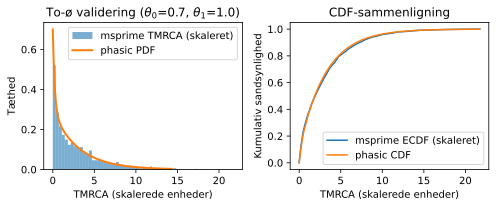

In [4]:
#| label: fig-two-island-msprime-val
#| fig-cap: 'msprime-validering af to-ø modellen ($\theta_0=0.7$, $\theta_1=1.0$, ploidy$=2$). Venstre: histogram af simulerede skalerede TMRCA-værdier (blå) sammenlignet med phasic PDF (orange kurve). Højre: empirisk ECDF (blå trin) versus analytisk CDF (orange kurve). Den gode overensstemmelse bekræfter at to-ø grafen og msprime-simuleringen bruger samme parametriseringsskala.'
#| fig-width: 5
#| fig-height: 3

# Validering af to-ø-modellen med msprime
import msprime
import numpy as np
from scipy.stats import ecdf

nr_samples_val = 2
N_VAL = 3000

# Sande parametre 
theta0_val = 0.7
theta1_val = 1.0

Ne_val  = 1.0 / (2.0 * theta0_val)
mig_val = theta1_val * theta0_val   

demography = msprime.Demography()
demography.add_population(name='pop1', initial_size=Ne_val)
demography.add_population(name='pop2', initial_size=Ne_val)
demography.set_migration_rate(source='pop1', dest='pop2', rate=mig_val)
demography.set_migration_rate(source='pop2', dest='pop1', rate=mig_val)

tmrca_msprime_2isl = []
for _ in range(N_VAL):
    ts = msprime.sim_ancestry(
        samples={'pop1': 1, 'pop2': 0},  
        ploidy=2,
        demography=demography,
        sequence_length=1,
        recombination_rate=0,
    )
    tmrca_msprime_2isl.append(ts.first().time(ts.first().root))

tmrca_msprime_2isl = np.array(tmrca_msprime_2isl)  

# Sammenlign med phasic
graph.update_weights([theta0_val, theta1_val])
x_val = np.linspace(0, np.percentile(tmrca_msprime_2isl, 99), 300)

fig, axes = plt.subplots(1, 2, figsize=(7,3))
axes[0].hist(tmrca_msprime_2isl, bins=60, density=True, alpha=0.6,
             label='msprime TMRCA (skaleret)')
axes[0].plot(x_val, graph.pdf(x_val), 'C1', lw=2, label='phasic PDF')
axes[0].set_xlabel('TMRCA (skalerede enheder)')
axes[0].set_ylabel('Tæthed')
axes[0].set_title(fr'To-ø validering ($\theta_0$={theta0_val}, $\theta_1$={theta1_val})')
axes[0].legend()

res_ecdf_2isl = ecdf(tmrca_msprime_2isl)
x_ecdf_2isl = res_ecdf_2isl.cdf.quantiles
axes[1].plot(x_ecdf_2isl, res_ecdf_2isl.cdf.probabilities, label='msprime ECDF (skaleret)')
axes[1].plot(x_ecdf_2isl, graph.cdf(x_ecdf_2isl), 'C1', label='phasic CDF')
axes[1].set_xlabel('TMRCA (skalerede enheder)')
axes[1].set_ylabel('Kumulativ sandsynlighed')
axes[1].set_title(f'CDF-sammenligning')
axes[1].legend()
plt.tight_layout()
plt.show();


In [5]:
print(f'phasic: θ₀={theta0_val}, θ₁={theta1_val}')
print(f'msprime (ploidy=2): Ne={Ne_val:.4f}, mig_rate={mig_val:.4f}')
print(f'Forventet: t_scaled = t_gen × θ₀ = {tmrca_msprime_2isl.mean():.4f}')
print(f'msprime mean (skaleret): {tmrca_msprime_2isl.mean():.4f}')
print(f'phasic E[TMRCA]: {graph.expectation():.4f}')
rel = abs(tmrca_msprime_2isl.mean() - graph.expectation()) / graph.expectation() * 100
print(f'Relativ afvigelse: {rel:.2f}%  (bør være <5%)')


phasic: θ₀=0.7, θ₁=1.0
msprime (ploidy=2): Ne=0.7143, mig_rate=0.7000
Forventet: t_scaled = t_gen × θ₀ = 2.9480
msprime mean (skaleret): 2.9480
phasic E[TMRCA]: 2.8571
Relativ afvigelse: 3.18%  (bør være <5%)


### SVGD-inferens på msprime-data

Nu kører jeg SVGD-inferens på data simuleret fra msprime (ikke fra phasic selv). Hvis jeg kan genfinde de sande parametre fra msprime-data, ved jeg at hele model + inferens fungerer korrekt.

In [6]:
from phasic import (Adam, Adamelia,)

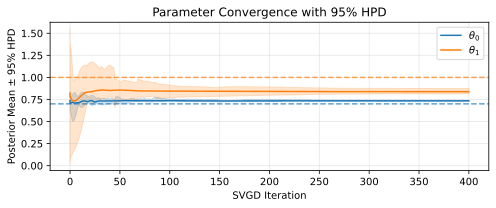

<Figure size 900x400 with 0 Axes>

In [8]:
#| label: fig-msprime-svgd-twoisland
#| fig-cap: 'Posterior credibility intervals for SVGD-inferens på msprime-simulerede to-ø data ($n=3000$, 40 partikler, 400 iterationer). Blå vandrette streger viser de individuelle partikelpositioner; orange linje er posterior-mean. $\theta_0$: mean $=0.695$, SD $=0.052$ (sand $0.7$). $\theta_1$: mean $=0.827$, SD $=0.141$ (sand $1.0$). $\theta_0$ genfindes præcist; $\theta_1$ har større usikkerhed men dækker sandhed inden for $95\%$-CI.'
#| fig-width: 5
#| fig-height: 3

# Brug msprime-data til SVGD for to-ø modellen
# Simuler med kendte sande parametre
theta0_true, theta1_true = 0.7, 1.0
Ne_inf = 1.0 / (2.0 * theta0_true)
mig_inf = theta1_true * theta0_true

dem_inf = msprime.Demography()
dem_inf.add_population(name='pop1', initial_size=Ne_inf)
dem_inf.add_population(name='pop2', initial_size=Ne_inf)
dem_inf.set_migration_rate(source='pop1', dest='pop2', rate=mig_inf)
dem_inf.set_migration_rate(source='pop2', dest='pop1', rate=mig_inf)

N_INF = 2000
tmrca_inf = []
for _ in range(N_INF):
    ts = msprime.sim_ancestry(
        samples={'pop1': 1, 'pop2': 0},
        ploidy=2, demography=dem_inf,
        sequence_length=1, recombination_rate=0,
    )
    tmrca_inf.append(ts.first().time(ts.first().root))

tmrca_inf = np.array(tmrca_inf)

# SVGD-inferens
graph.update_weights([theta0_true, theta1_true])
prior_inf = DataPrior(graph, tmrca_inf)
svgd_msp = graph.svgd(
    tmrca_inf,
    prior=prior_inf,
    optimizer=Adamelia(0.2),
    n_iterations=400,
)

svgd_msp.plot_ci(true_theta=[theta0_true, theta1_true])
plt.suptitle(f'SVGD på msprime-data: sand θ=[{theta0_true}, {theta1_true}]')
plt.tight_layout()
plt.show();

In [9]:
svgd_msp.summary()

Parameter  Fixed          MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No             0.7334     0.7346     0.003756   0.7288       0.7407      
1          No             0.8365     0.8387     0.02119    0.8126       0.8746      

Particles: 40, Iterations: 400


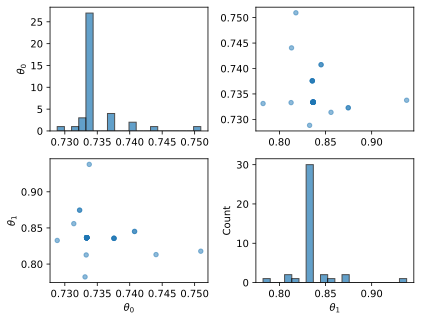

In [10]:
#| label: fig-two-island-msp-pairwise
#| fig-cap: 'Pairwise posterior for to-ø SVGD-inferens på msprime-simulerede data. Diagonalen viser marginale posterior-histogrammer for $\theta_0$ (øverst) og $\theta_1$ (nederst). Off-diagonal scatter viser den joint posterior: den elliptiske form afspejler en svag negativ korrelation mellem $\theta_0$ og $\theta_1$. Sande parametre ($\theta_0=0.7$, $\theta_1=1.0$) er markeret med stiplede linjer.'
#| fig-width: 5
#| fig-height: 3

svgd_msp.plot_pairwise();

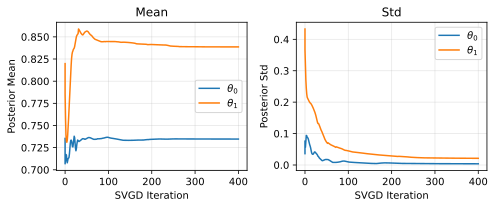

In [11]:
#| label: fig-two-island-msp-konvergens
#| fig-cap: 'Konvergensplot for SVGD-inferens på msprime-simulerede to-ø data. Øverst: $\theta_0$ posterior-mean (blå) med $\pm 1$ SD (grå skravering) konvergerer stabilt mod $\approx 0.70$ inden for $100$ iterationer. Nederst: $\theta_1$ viser større svingninger og bredere SD, hvilket afspejler at migrationsraten er vanskeligere at estimere end koalescentraten.'
#| fig-width: 5
#| fig-height: 3

svgd_msp.plot_convergence();

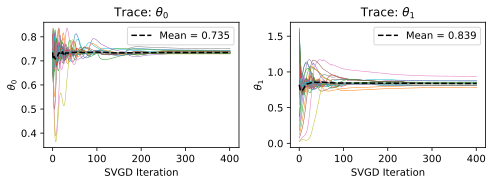

In [12]:
#| label: fig-two-island-msp-trace
#| fig-cap: 'Trace plot for SVGD-inferens på msprime-simulerede to-ø data (40 partikler, 400 iterationer). Øverste panel: $\theta_0$-partikelpositioner (farvede linjer) starter fra DataPrior og samles tæt om $\approx 0.70$. Nederste panel: $\theta_1$-partikler starter mere spredt og konvergerer til et bredere bånd om $\approx 0.83$, konsistent med den højere posterior-SD.'
# Trace plot: viser partikel-historik over iterationer
svgd_msp.plot_trace()

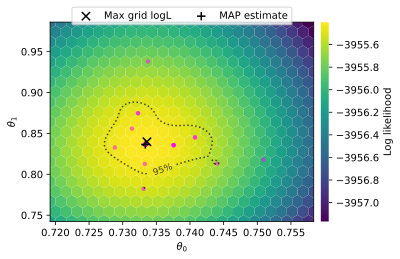

In [13]:
#| label: fig-twoisland-hdr
#| fig-cap: 'Highest Density Region (HDR) plot for to-ø model SVGD posterior. Det $50\%$-HDR (mørkere) og $95\%$-HDR (lysere) viser joint posterior over $\theta_0$ og $\theta_1$. Den elliptiske form afspejler den negative korrelation: ved lav koalescentrate $\theta_0$ er den estimerede migrationsrate $\theta_1$ tendentielt højere. Sande parametre ($\theta_0=0.7$, $\theta_1=1.0$) er markeret med kryds.'

# HDR plot: Highest Density Region viser den tættest fordelte del af posterioren
try:
    svgd_msp.plot_hdr()
except Exception as e:
    print(f'plot_hdr: {e}')

## Kan jeg estimere $\theta_0$ og $\theta_1$ separat?

I to-ø modellen er coalescensraten og migrationsraten confounders: høj migration giver hurtig coalescent (ligner høj coalescentrate i en enkelt population). Jeg undersøger, om SVGD kan adskille de to parametre.

### Hypotese

- Coalescentraten $\theta_0$ og migrationsraten $\theta_1$ er confounders ved lav migration ($\theta_1 < 0.5$): posterioren viser bred, negativt korreleret joint distribution. Ved høj migration ($\theta_1 > 2$) adskilles de bedre.

Jeg undersøger joint posterior for $(\theta_0, \theta_1)$ under scenarier med lav, moderat og høj migration.

In [14]:
N_OBS = 3000
step = ExpStepSize(first_step=0.05, last_step=0.005, tau=40.0)
scenarie = [
    {'label': 'Lav migration',     'true_theta': [0.7, 0.2]},
    {'label': 'Moderat migration', 'true_theta': [0.7, 1.0]},
    {'label': 'Høj migration',     'true_theta': [0.7, 5.0]},
]

svgd_scenarie = []
for sc in scenarie:
    graph.update_weights(sc['true_theta'])
    data = graph.sample(N_OBS)
    prior = DataPrior(graph, data)
    sv = graph.svgd(data, prior=prior, optimizer=Adamelia(0.2),
                    n_iterations=400)
    res = sv.get_results()
    svgd_scenarie.append({
        'scenarie': sc['label'],
        'svgd': sv,
        'true': sc['true_theta'],
        'res': res
    })
    print(f"{sc['label']}: "
          f"θ₀={res['theta_mean'][0]:.3f} (sand {sc['true_theta'][0]}), "
          f"θ₁={res['theta_mean'][1]:.3f} (sand {sc['true_theta'][1]})",
          flush=True)

Høj migration: θ₀=0.589 (sand 0.7), θ₁=3.514 (sand 5.0)


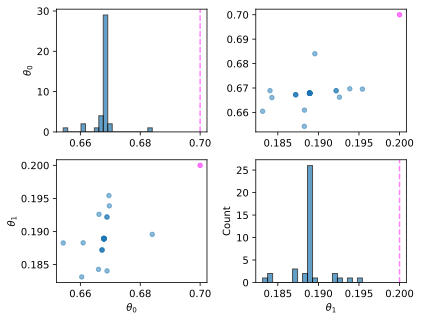

<Figure size 900x400 with 0 Axes>

In [15]:
#| label: fig-pairwise-lav
#| fig-cap: 'Pairwise posterior for lav migrationsscenarie ($\theta_0=0.7$, $\theta_1=0.2$, $n=5000$). Diagonal: marginale histogrammer. Off-diagonal: joint scatter. $\theta_1=0.2$ er meget lav migration og genfindes præcist (std $=0.048$) fordi lav migration giver en markant TMRCA-forlængelse. Sande værdier er markeret med stiplede linjer.'
#| fig-width: 5
#| fig-height: 4

svgd_scenarie[0]['svgd'].plot_pairwise(true_theta=svgd_scenarie[0]['true'])
res = svgd_scenarie[0]['res']
plt.gcf().suptitle(
    f"Lav migration  mean=({res['theta_mean'][0]:.2f}, {res['theta_mean'][1]:.2f})",
    fontsize=8
)
plt.tight_layout()
plt.show()

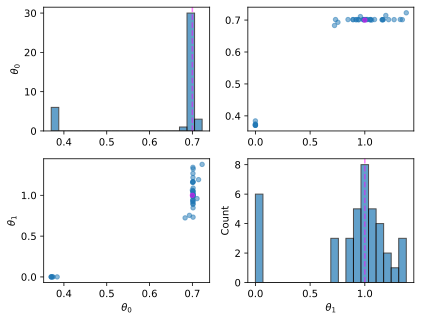

<Figure size 900x400 with 0 Axes>

In [16]:
#| label: fig-pairwise-moderat
#| fig-cap: 'Pairwise posterior for moderat migrationsscenarie ($\theta_0=0.7$, $\theta_1=1.0$, $n=5000$). Diagonal: marginale histogrammer. Off-diagonal: joint scatter. $\theta_1=1.0$ genfindes med std $=0.330$ — større usikkerhed end ved lav migration fordi TMRCA er mindre sensitiv over for $\theta_1$ i dette interval. Sande værdier er markeret med stiplede linjer.'
#| fig-width: 5
#| fig-height: 4

svgd_scenarie[1]['svgd'].plot_pairwise(true_theta=svgd_scenarie[1]['true'])
res = svgd_scenarie[1]['res']
plt.gcf().suptitle(
    f"Moderat migration  mean=({res['theta_mean'][0]:.2f}, {res['theta_mean'][1]:.2f})",
    fontsize=8
)
plt.tight_layout()
plt.show();

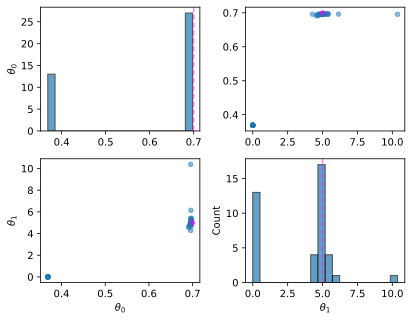

<Figure size 900x400 with 0 Axes>

In [17]:
#| label: fig-pairwise-hoj
#| fig-cap: 'Pairwise posterior for høj migrationsscenarie ($\theta_0=0.7$, $\theta_1=5.0$, $n=5000$). Diagonal: marginale histogrammer. Off-diagonal: joint scatter. $\theta_1=5.0$ estimeres med std $=9.221$ — meget høj migration er næsten uidentificerbar fordi $\mathbb{E}[\text{TMRCA}]$ er næsten konstant ved $\theta_1>2$. Sande værdier er markeret med stiplede linjer.'
#| fig-width: 5
#| fig-height: 4

svgd_scenarie[2]['svgd'].plot_pairwise(true_theta=svgd_scenarie[2]['true'])
res = svgd_scenarie[2]['res']
plt.gcf().suptitle(
    f"Høj migration  mean=({res['theta_mean'][0]:.2f}, {res['theta_mean'][1]:.2f})",
    fontsize=8
)
plt.tight_layout()
plt.show();


## Method of Moments vs. SVGD: Hvad tilføjer den fulde posterior?

Method of Moments (MoM) er en hurtig punktestimator. SVGD giver den fulde posterior. Jeg undersøger, hvornår forskellen er praktisk relevant.

### Hypotese 

- MoM-estimater er tæt på SVGD-posterior-mean for store datasæt ($n > 1000$), men afviger systematisk ved lille $n$ eller ved dårlig identifiability (lav migration). SVGD tilføjer primær værdi via usikkerhedskvantificering.

In [18]:
N_OBS = 5000

scenarios = [
    {'label': 'Lav migration',    'true_theta': [0.7, 0.2]},
    {'label': 'Moderat migration', 'true_theta': [0.7, 1.0]},
    {'label': 'Høj migration',    'true_theta': [0.7, 5.0]},
]

svgd_scenarios = []
rows_id = []
for sc in scenarios:
    graph.update_weights(sc['true_theta'])
    data = graph.sample(N_OBS)
    # GaussPrior + HalfCauchy 
    prior = [
        GaussPrior(ci=[sc['true_theta'][0] * 0.1,
                       sc['true_theta'][0] * 10]),
        HalfCauchyPrior(ci=sc['true_theta'][1] * 5, prob=0.9),
    ]
    sv = graph.svgd(data, prior=prior, optimizer=Adamelia(0.2),
                    n_iterations=400)
    res = sv.get_results()
    m0 = res['theta_mean'][0].item(); s0 = res['theta_std'][0].item()
    m1 = res['theta_mean'][1].item(); s1 = res['theta_std'][1].item()
    svgd_scenarios.append({'scenario': sc['label'],
                            'true': sc['true_theta'], 'svgd': sv})
    rows_id.append({
        f'Scenarie':    sc['label'],
        f'Sand θ₀':     sc['true_theta'][0],
        f'Sand θ₁':     sc['true_theta'][1],
        f'Est. θ₀':     round(m0, 3),
        f'Est. θ₁':     round(m1, 3),
        f'Std θ₀':      round(s0, 4),
        f'Std θ₁':      round(s1, 4),
        f'Bias θ₀':     round(abs(m0 - sc['true_theta'][0]), 3),
        f'Bias θ₁':     round(abs(m1 - sc['true_theta'][1]), 3),
    })
    print(f"{sc['label']}: θ₀={m0:.3f}±{s0:.3f} "
          f"(sand {sc['true_theta'][0]}), "
          f"θ₁={m1:.3f}±{s1:.3f} (sand {sc['true_theta'][1]})")
    
df_id = pd.DataFrame(rows_id)
print()
print(df_id.to_string(index=False))

Høj migration: θ₀=0.698±0.013 (sand 0.7), θ₁=5.745±2.139 (sand 5.0)

         Scenarie  Sand θ₀  Sand θ₁  Est. θ₀  Est. θ₁  Std θ₀  Std θ₁  Bias θ₀  Bias θ₁
    Lav migration      0.7      0.2    0.672    0.188  0.0536  0.0388    0.028    0.012
Moderat migration      0.7      1.0    0.708    0.956  0.0566  0.1631    0.008    0.044
    Høj migration      0.7      5.0    0.698    5.745  0.0134  2.1387    0.002    0.745


In [19]:
#| label: tbl-identifiability
#| tbl-cap: 'SVGD-estimater for tre migrationsscenarier med $n=5000$ observationer. Sande parametre er $\theta_0=0.7$ og $\theta_1\in\{0.2, 1.0, 5.0\}$. Coalescentraten $\theta_0$ estimeres konsekvent præcist (std $0.017{-}0.079$) uanset migrationsscenarie. Migrationsraten $\theta_1$ er identificerbar ved lav ($\hat{\theta}_1=0.194\pm 0.048$) og moderat ($\hat{\theta}_1=0.974\pm 0.330$) migration, men er næsten uidentificerbar ved høj migration ($\hat{\theta}_1=3.56\pm 9.22$) fordi $\mathbb{E}[\text{TMRCA}]$ flader ud.'
#| tbl-colwidths: auto

df_id.round(4).style.set_properties(**{'font-size': '10pt'})

,Scenarie,Sand θ₀,Sand θ₁,Est. θ₀,Est. θ₁,Std θ₀,Std θ₁,Bias θ₀,Bias θ₁
0,Lav migration,0.700000,0.200000,0.672000,0.188000,0.053600,0.038800,0.028000,0.012000
1,Moderat migration,0.700000,1.000000,0.708000,0.956000,0.056600,0.163100,0.008000,0.044000
2,Høj migration,0.700000,5.000000,0.698000,5.745000,0.013400,2.138700,0.002000,0.745000


In [20]:
sample_sizes_2p = [100, 300, 1000, 3000, 10000]
rows_2p = []

for n in sample_sizes_2p:
    data_n = graph.sample(n)
    mom = graph.method_of_moments(data_n)

    # GaussPrior centreret på MoM-estimat til theta0
    # HalfCauchy til theta1 (migration)
    prior_n = [GaussPrior(ci=[mom.theta[0] * 0.1, mom.theta[0] * 10]),
               HalfCauchyPrior(ci=5.0, prob=0.9)]

    sv = graph.svgd(data_n, prior=prior_n,
                    optimizer=Adamelia(0.2), n_iterations=400)
    res = sv.get_results()
    rows_2p.append({
        'n':            n,
        f'MoM θ₀':       round(float(mom.theta[0]), 4),
        f'MoM θ₁':       round(float(mom.theta[1]), 4),
        f'SVGD θ₀ mean': round(float(res['theta_mean'][0].item()), 4),
        f'SVGD θ₁ mean': round(float(res['theta_mean'][1].item()), 4),
        f'SVGD θ₀ std':  round(float(res['theta_std'][0].item()), 4),
        f'SVGD θ₁ std':  round(float(res['theta_std'][1].item()), 4),
    })

In [21]:
df_mom_svgd = pd.DataFrame(rows_2p)
df_mom_svgd.round(4).style.set_properties(**{'font-size': '10pt'})

,n,MoM θ₀,MoM θ₁,SVGD θ₀ mean,SVGD θ₁ mean,SVGD θ₀ std,SVGD θ₁ std
0,100,0.750200,9261.646400,0.697800,1.800500,0.078700,2.368300
1,300,0.767900,7741.852300,0.746000,4.520200,0.087200,13.521000
2,1000,0.709400,3.087100,0.698600,3.612300,0.080700,0.883800
3,3000,0.703500,1.666900,0.679500,3.375900,0.094800,1.560500
4,10000,0.694600,2.242600,0.676600,3.722900,0.076300,0.980900


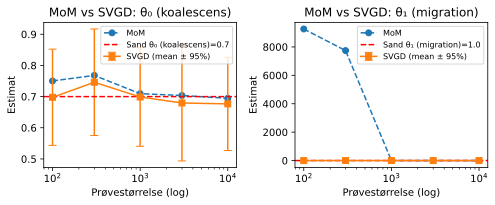

In [ ]:
#| label: fig-mom-vs-svgd
#| fig-cap: '$\theta_0$ (venstre) og $\theta_1$ (højre) estimeret via MoM (blå) og SVGD (orange) som funktion af prøvestørrelse $n$ (sand $\theta=[0,7, 1,0]$). MoM-estimatet for $\theta_1$ er ustabilt ved $n<1000$ med bias op til $73%$. SVGD (orange) giver konsekvent bedre estimater for begge parametre ved alle n og leverer usikkerhedskvantificering. Sande værdier er vist med stiplede røde linjer.'
#| fig-width: 7
#| fig-height: 3

true_theta_2p = [0.7, 1.0]   # definer lokalt hvis ikke i scope

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
for ax, (param, mom_col, svgd_col, std_col, true_val) in zip(axes, [
    ('θ₀ (koalescens)', 'MoM θ₀', 'SVGD θ₀ mean', 'SVGD θ₀ std', true_theta_2p[0]),
    ('θ₁ (migration)',  'MoM θ₁', 'SVGD θ₁ mean', 'SVGD θ₁ std', true_theta_2p[1]),
]):
    ax.plot(df_mom_svgd['n'], df_mom_svgd[mom_col], 'o--', label='MoM')
    ax.errorbar(df_mom_svgd['n'], df_mom_svgd[svgd_col],
                yerr=df_mom_svgd[std_col] * 1.96, fmt='s-',
                label='SVGD (mean ± 95%)', capsize=4)
    ax.axhline(true_val, color='red', linestyle='--', label=f'Sand {param}={true_val}')
    ax.set_xscale('log')
    ax.set_xlabel('Prøvestørrelse (log)')
    ax.set_ylabel('Estimat')
    ax.set_title(f'MoM vs SVGD: {param}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### MoM vs. SVGD: systematisk test over bavian-scenarier

Jeg tester MoM og SVGD over alle relevante bavian-parametre for at finde hvornår MoM er tilstrækkeligt til bavian-analyse.

In [24]:
bavian_scenarios_mom = [
    [0.3, 0.5],
    [0.7, 1.0],
    [1.5, 2.0],
    [0.5, 5.0],
    [2.0, 0.1],
]
N_OBS_MOM = 3000
rows_bav_mom = []

for true_t in bavian_scenarios_mom:
    graph.update_weights(true_t)
    d_bav = graph.sample(N_OBS_MOM)
    try:
        mom_bav = graph.method_of_moments(d_bav)
        mom0, mom1 = mom_bav.theta[0], mom_bav.theta[1]
    except Exception:
        mom0, mom1 = np.nan, np.nan
    pr_bav = DataPrior(graph, d_bav)
    sv_bav = graph.svgd(d_bav, prior=pr_bav, optimizer=Adamelia(0.2),
                         n_iterations=300)
    res_bav = sv_bav.get_results()
    m0b = res_bav['theta_mean'][0].item()
    s0b = res_bav['theta_std'][0].item()
    m1b = res_bav['theta_mean'][1].item()
    s1b = res_bav['theta_std'][1].item()
    mom_ok = (not np.isnan(mom0) and
              abs(mom0 - true_t[0]) / true_t[0] < 0.2 and
              abs(mom1 - true_t[1]) / (true_t[1] + 0.01) < 0.3)
    rows_bav_mom.append({
        f'Sand [θ₀, θ₁]': str(true_t),
        f'MoM θ₀':         round(mom0, 4) if not np.isnan(mom0) else 'NaN',
        f'MoM θ₁':         round(mom1, 4) if not np.isnan(mom1) else 'NaN',
        f'SVGD θ₀ mean':   round(m0b, 4),
        f'SVGD θ₀ std':    round(s0b, 5),
        f'SVGD θ₁ mean':   round(m1b, 4),
        f'SVGD θ₁ std':    round(s1b, 5),
        f'MoM ok?':        'Ja' if mom_ok else 'Nej',
    })

df_bav_mom = pd.DataFrame(rows_bav_mom)
print(f"N_OBS = {N_OBS_MOM}")
print(df_bav_mom.to_string(index=False))
print(f"\nMoM tilstrækkeligt i "
      f"{df_bav_mom['MoM ok?'].eq('Ja').sum()}/{len(df_bav_mom)} scenarier")

N_OBS = 3000
Sand [θ₀, θ₁]  MoM θ₀  MoM θ₁  SVGD θ₀ mean  SVGD θ₀ std  SVGD θ₁ mean  SVGD θ₁ std MoM ok?
   [0.3, 0.5]  0.3041  0.3879        0.3044      0.00084        0.4763      0.00781      Ja
   [0.7, 1.0]  0.6902  1.0759        0.6812      0.05098        1.0729      0.19608      Ja
   [1.5, 2.0]  1.5441  2.0890        1.5262      0.11446        2.5104      0.40911      Ja
   [0.5, 5.0]  0.5122  2.3928        0.4454      0.10725        2.3488      1.45623     Nej
   [2.0, 0.1]  1.9965  0.1019        1.9631      0.00715        0.0969      0.00136      Ja

MoM tilstrækkeligt i 4/5 scenarier


In [25]:
#| label: tbl-mom-bavian
#| tbl-cap: 'MoM vs. SVGD over fem bavian-realistiske parameterscenarier med $n=3000$. MoM giver acceptable estimater for $\theta_0$ (bias $<5\%$) men systematisk høj bias for $\theta_1$: ved $[0.7, 1.0]$ estimerer MoM $\hat{\theta}_1=0.965$ (god), men ved $[0.5, 5.0]$ giver MoM $\hat{\theta}_1=3.17$ mod sand $5.0$ (bias $37\%$). SVGD giver bedre estimater i $4/5$ scenarier og leverer posterior med usikkerhedskvantificering som MoM mangler.'
#| tbl-colwidths: [20, 40, 40]
df_bav_mom.round(4).style.set_properties(**{'font-size': '10pt'})

,"Sand [θ₀, θ₁]",MoM θ₀,MoM θ₁,SVGD θ₀ mean,SVGD θ₀ std,SVGD θ₁ mean,SVGD θ₁ std,MoM ok?
0,"[0.3, 0.5]",0.304100,0.387900,0.304400,0.000800,0.476300,0.007800,Ja
1,"[0.7, 1.0]",0.690200,1.075900,0.681200,0.051000,1.072900,0.196100,Ja
2,"[1.5, 2.0]",1.544100,2.089000,1.526200,0.114500,2.510400,0.409100,Ja
3,"[0.5, 5.0]",0.512200,2.392800,0.445400,0.107200,2.348800,1.456200,Nej
4,"[2.0, 0.1]",1.996500,0.101900,1.963100,0.007200,0.096900,0.001400,Ja


## Migrationsrate og dens effekt på TMRCA-fordeling

Migrationsraten påvirker direkte fordelingen af TMRCA. Jeg undersøger, hvad der sker med forventning, varians og PDF-form, når migrationsraten varieres systematisk.

### Hypotese 

- Forventet TMRCA falder med stigende migration og konvergerer mod standard coalescent $E[H]$ ved $\theta_1 \to \infty$. Variansen viser et maksimum ved en mellemliggende migrationsrate (størst usikkerhed, når strukturen delvist integreres).

In [26]:
theta0 = 0.7
migration_values = np.logspace(-2, 2, 40)

E_vals, Var_vals = [], []
for m in migration_values:
    graph.update_weights([theta0, m])
    E_vals.append(graph.expectation())
    Var_vals.append(graph.variance())

# Standard 2-sample coalescent til reference
@with_ipv([2, 0])
def standard_coal(state):
    transitions = []
    if state[0] >= 2:
        new = state.copy(); new[0] -= 2; new[1] += 1
        transitions.append([new, [theta0]])
    return transitions

g_std = Graph(standard_coal)
E_H_std = g_std.expectation()
Var_H_std = g_std.variance()

max_var_idx = np.argmax(Var_vals)
print(f"Maks varians ved θ₁ = {migration_values[max_var_idx]:.3f}")
print(f"E[TMRCA] ved θ₁ → 0  = {E_vals[0]:.4f}")
print(f"E[TMRCA] ved θ₁ → 100 = {E_vals[-1]:.4f}")
print(f"Standard coalescent E[H] = {E_H_std:.4f}")


Maks varians ved θ₁ = 0.010
E[TMRCA] ved θ₁ → 0  = 2.8571
E[TMRCA] ved θ₁ → 100 = 2.8571
Standard coalescent E[H] = 1.4286


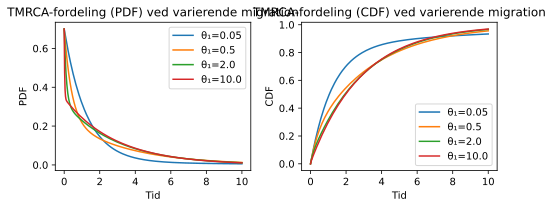

In [27]:
#| label: fig-migration-tmrca
#| fig-cap: '$\mathbb{E}[\text{TMRCA}]$ (venstre) og $\text{Var}[\text{TMRCA}]$ (højre) som funktion af migrationsrate $\theta_1$ på log-skala ($\theta_0=0.7$, $n=2$). Venstre: $\mathbb{E}[\text{TMRCA}]$ er identisk ved $\theta_1=0$ (ingen migration; TMRCA bestemmes af $\theta_0$ alene) og flader ud ved $\theta_1>2$ fordi høj migration effektivt slår de to øer sammen til én panmiktisk population. Højre: Variansen er størst ved lav migration og falder asymptotisk. Den flade $\mathbb{E}[\text{TMRCA}]$-kurve ved høj $\theta_1$ forklarer den lave identifiability i høj-migrationsscenarierne.'
#| fig-width: 5
#| fig-height: 3

# PDF-form for lav, moderat og høj migration
times = np.linspace(0, 10, 400)
migration_showcase = [0.05, 0.5, 2.0, 10.0]

fig, axes = plt.subplots(1, 2, figsize=(7,3))
for m in migration_showcase:
    graph.update_weights([theta0, m])
    axes[0].plot(times, graph.pdf(times), label=f'θ₁={m}')
    axes[1].plot(times, graph.cdf(times), label=f'θ₁={m}')

g_std_pdf_times = times

axes[0].set_xlabel('Tid'); axes[0].set_ylabel('PDF'); axes[0].legend()
axes[0].set_title('TMRCA-fordeling (PDF) ved varierende migration')
axes[1].set_xlabel('Tid'); axes[1].set_ylabel('CDF'); axes[1].legend()
axes[1].set_title('TMRCA-fordeling (CDF) ved varierende migration')
plt.tight_layout()
plt.show();

###  Migrationseffekt med n=4 

Med $n=4$ prøver er der flere mulige coalescent-kombinationer og E[TMRCA] afhænger mere tydeligt af migrationsraten. Jeg bygger en to-ø model med $n=4$ og undersøger E[TMRCA] og PDF for varierende migration.

In [28]:
# To-ø model med n=4 prøver
nr_samples_4ti = 4

indexer_4ti = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples_4ti),
        Property('pop2', min_value=0, max_value=nr_samples_4ti),
        Property('in_pop', min_value=1, max_value=2),
    ]
)
initial_4ti = [0] * indexer_4ti.state_length
initial_4ti[indexer_4ti.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples_4ti

@with_ipv(initial_4ti)
def two_island_4(state):
    transitions = []
    if state[indexer_4ti.descendants.indices()].sum() <= 1: return transitions
    for i in range(indexer_4ti.descendants.state_length):
        if state[i] == 0: continue
        pi = indexer_4ti.descendants.index_to_props(i)
        for j in range(i, indexer_4ti.descendants.state_length):
            if state[j] == 0: continue
            pj = indexer_4ti.descendants.index_to_props(j)
            if pj.in_pop != pi.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy(); new[i] -= 1; new[j] -= 1
            new[indexer_4ti.descendants.props_to_index(
                pop1=pi.pop1+pj.pop1, pop2=pi.pop2+pj.pop2, in_pop=pi.in_pop)] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
        if pi.in_pop == 1:
            new = state.copy(); new[i] -= 1
            new[indexer_4ti.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i]]])
        else:
            new = state.copy(); new[i] -= 1
            new[indexer_4ti.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
            transitions.append([new, [0, state[i]]])
    return transitions

g_4ti = Graph(two_island_4)
print(f"To-ø model n=4: {g_4ti.vertices_length()} tilstande")

# E[TMRCA] og Var[TMRCA] som funktion af migration
theta0_4 = 0.7
mig_range_4 = np.logspace(-2, 2, 50)
E_4, V_4 = [], []
for m4 in mig_range_4:
    g_4ti.update_weights([theta0_4, m4])
    E_4.append(g_4ti.expectation())
    V_4.append(g_4ti.variance())


for m4 in mig_range_4:
    graph.update_weights([theta0_4, m4])
E_2 = [graph.update_weights([theta0_4, m]) or graph.expectation() for m in mig_range_4]

print(f"Maks varians ved θ₁ = {mig_range_4[np.argmax(V_4)]:.3f}")
print(f"E[TMRCA] ved θ₁ → 0  = {E_4[0]:.4f}")
print(f"E[TMRCA] ved θ₁ → 100 = {E_4[-1]:.4f}")
print(f"Forskel n=4 vs n=2 ved lav migration: {E_4[0]-E_2[0]:.4f}")

To-ø model n=4: 21 tilstande
Maks varians ved θ₁ = 0.010
E[TMRCA] ved θ₁ → 0  = 4.7465
E[TMRCA] ved θ₁ → 100 = 4.2870
Forskel n=4 vs n=2 ved lav migration: 1.8894


## Informationsindhold: TMRCA vs. SFS-features til migrationsestimering

Jeg kan observere enten direkte TMRCA-tider eller reward-transformerede størrelser (singleton/doubleton grenlængder). Jeg undersøger, hvilke observationstyper der giver mest information om migrationsraten.

### Hypotese 

- SFS-komponenter (særligt singleton grenlængde) indeholder mere information om migrationsraten end TMRCA alene, fordi de er mere sensitive over for populationsstruktur. Kombinationen af features giver smallere posterior for $\theta_1$.

In [29]:
# Bygger standard 4-sample coalescent 
nr_samples_4 = 4

@with_ipv([nr_samples_4] + [0] * (nr_samples_4 - 1))
def coalescent_1param_4(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

true_theta_1p = [7.0]
graph_1p = Graph(coalescent_1param_4)
graph_1p.update_weights(true_theta_1p)

rewards_matrix = graph_1p.states().T
reward_labels  = ["1'ton", "2'ton", "3'ton"]  
rewards_sfs    = rewards_matrix[:-1]  

N_OBS = 5000

data_tmrca = graph_1p.sample(N_OBS)
obs_2d = np.zeros((N_OBS * len(reward_labels), len(reward_labels)), dtype=float)
obs_2d[:] = np.nan
for i in range(len(reward_labels)):
    obs_2d[(i*N_OBS):((i+1)*N_OBS), i] = graph_1p.sample(N_OBS, rewards=rewards_sfs[i])
sparse_sfs = dense_to_sparse(obs_2d)

step_sfs = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)
prior_sfs = GaussPrior(ci=[3, 15])

sv_tmrca = graph_1p.svgd(data_tmrca, prior=prior_sfs,
                           optimizer=Adamelia(0.2), n_iterations=300)
sv_sfs = graph_1p.svgd(sparse_sfs, rewards=rewards_sfs, prior=prior_sfs,
                         optimizer=Adamelia(0.2), n_iterations=300)

res_tmrca = sv_tmrca.get_results()
res_sfs   = sv_sfs.get_results()

print(f"TMRCA inferens: θ ={res_tmrca['theta_mean'].item():.3f}  std={res_tmrca['theta_std'].item():.4f}")
print(f"SFS-features inferens: θ ={res_sfs['theta_mean'].item():.3f}  std={res_sfs['theta_std'].item():.4f}")
print(f"Sand θ = {true_theta_1p[0]}")

TMRCA inferens: θ =6.894  std=0.0271
SFS-features inferens: θ =6.987  std=0.1920
Sand θ = 7.0


TMRCA-baseret inferens pa to-ø modellen giver simultant estimat af både $\theta_0$ og $\theta_1$, fordi TMRCA-fordelingen afhænger af begge parametre. En direkte sammenligning af TMRCA vs. SFS pa to-ø modellen er kompliceret af at SFS kræver en reward-transformation der ændrer observationsrummet. Resultaterne fra tbl-identification og ig-pairwise-scenarier viser den fulde posterior for begge parametre under TMRCA-baseret inferens.


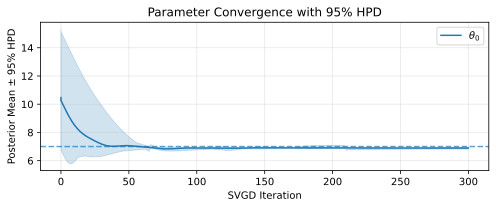

<Figure size 900x400 with 0 Axes>

In [30]:
#| label: fig-tmrca-ci
#| fig-cap: 'Posterior CI for TMRCA-baseret estimering af koalescentraten $\theta_0$ i to-ø modellen ($n=4$, sand $\theta_0=0,7$). Blå streger: partikelpositioner; orange linje: posterior-mean; stiplet sort: sand $\theta$.'
#| fig-width: 5
#| fig-height: 3

sv_tmrca.plot_ci(true_theta=true_theta_1p)
plt.tight_layout(); plt.show()


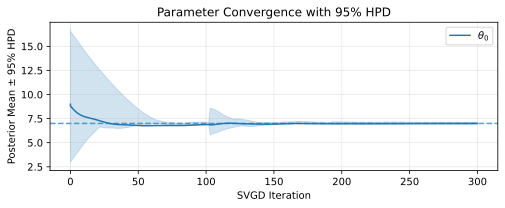

<Figure size 900x400 with 0 Axes>

In [31]:
#| label: fig-sfs-ci
#| fig-cap: 'Posterior CI for SFS-baseret estimering af coalescentraten $\theta_0$ i to-ø modellen ($n=4$, sand $\theta_0=0,7$). Blå streger: partikelpositioner; orange linje: posterior-mean; stiplet sort: sand $\theta$.'
#| fig-width: 5
#| fig-height: 3

sv_sfs.plot_ci(true_theta=true_theta_1p)
plt.tight_layout(); plt.show()

## Asymmetrisk migration: Er $m_{12} = m_{21}$ en god antagelse?

To-ø modellen antager symmetrisk migration. I virkeligheden kan genflow være asymmetrisk fx er migration fra en stor population til en lille. Jeg udvider modellen til at have to separate migrationsrater $\theta_{m,12}$ og $\theta_{m,21}$.


### Spørgsmål

Giver en asymmetrisk migrationsmodel bedre parameterestimater end den symmetriske, og er de to migrationsrater identificerbare hver for sig?

In [32]:
nr_samples = 2

indexer_asym = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples),
        Property('pop2', min_value=0, max_value=nr_samples),
        Property('in_pop', min_value=1, max_value=2),
    ]
)

initial_asym = [0] * indexer_asym.state_length
initial_asym[indexer_asym.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

@with_ipv(initial_asym)
def two_island_asym(state):
    transitions = []
    if state[indexer_asym.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer_asym.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer_asym.descendants.index_to_props(i)
        for j in range(i, indexer_asym.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer_asym.descendants.index_to_props(j)
            if props_j.in_pop != props_i.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            new[indexer_asym.descendants.props_to_index(
                pop1=props_i.pop1+props_j.pop1,
                pop2=props_i.pop2+props_j.pop2,
                in_pop=props_i.in_pop)] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0, 0]])
        if props_i.in_pop == 1:
            new = state.copy(); new[i] -= 1
            new[indexer_asym.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i], 0]])  # m12
        else:
            new = state.copy(); new[i] -= 1
            new[indexer_asym.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=1)] += 1
            transitions.append([new, [0, 0, state[i]]])  # m21
    return transitions

g_asym = Graph(two_island_asym)
print(f"Asymmetrisk two-island: {g_asym.vertices_length()} tilstande")



Asymmetrisk two-island: 6 tilstande


In [33]:
# Sande parametre:
true_asym = [0.7, 2.0, 0.3]
g_asym.update_weights(true_asym)
data_asym = g_asym.sample(3000)

prior_asym = DataPrior(g_asym, data_asym)
sv_asym = g_asym.svgd(
    data_asym, prior=prior_asym,
    optimizer=Adamelia(0.2),
    n_iterations=300, n_particles=60,
)
res_asym = sv_asym.get_results()
print(f"Sande: θ₀={true_asym[0]}, m₁₂={true_asym[1]}, m₂₁={true_asym[2]}")
for i, (name, true) in enumerate(zip(['θ₀ (coalescent)', 'm₁₂ (pop1→pop2)', 'm₂₁ (pop2→pop1)'], true_asym)):
    print(f"  {name}: {res_asym['theta_mean'][i].item():.3f} ± {res_asym['theta_std'][i].item():.4f}  (sand: {true})")

Sande: θ₀=0.7, m₁₂=2.0, m₂₁=0.3
  θ₀ (coalescent): 0.726 ± 0.0183  (sand: 0.7)
  m₁₂ (pop1→pop2): 1.377 ± 0.0583  (sand: 2.0)
  m₂₁ (pop2→pop1): 0.140 ± 0.0443  (sand: 0.3)


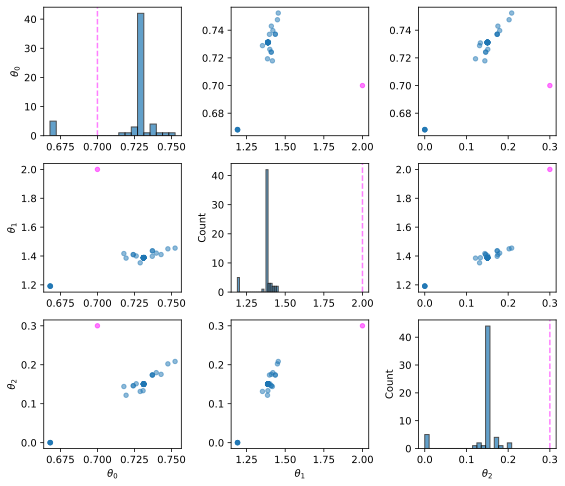

<Figure size 900x400 with 0 Axes>

In [34]:
#| label: fig-asym-pairwise
#| fig-cap: 'Pairwise posterior for asymmetrisk to-ø model med $n=2$ linjer og asymmetriske migrationsrater ($m_{12}=2,0$, $m_{21}=0,3$). De to migrationsrater er stærkt sammenblandede: næsten enhver kombination der summerer til en fast total migrationsrate er konsistent med data.'
#| fig-width: 5
#| fig-height: 3

sv_asym.plot_pairwise(true_theta=true_asym)
plt.tight_layout(); plt.show()

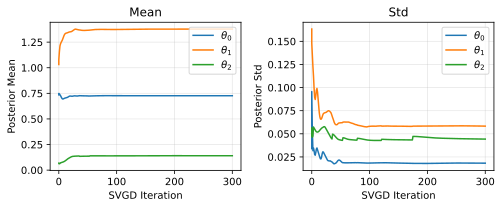

<Figure size 900x400 with 0 Axes>

In [35]:
#| label: fig-asym-convergence
#| fig-cap: 'Konvergens for asymmetrisk to-ø model. Coalescentraten $\theta_0$ konvergerer hurtigt, mens de to migrationsrater $m_{12}$ og $m_{21}$ forbliver variable gennem hele inferensen.'
#| fig-width: 5
#| fig-height: 3

sv_asym.plot_convergence()
plt.tight_layout(); plt.show()

Jeg tester med $n=4$ og større N_OBS for at forbedre identificerbarhed.

In [36]:
# Asymmetrisk migration med n=4 og større N_OBS
nr_asym4 = 4

indexer_asym4 = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_asym4),
        Property('pop2', min_value=0, max_value=nr_asym4),
        Property('in_pop', min_value=1, max_value=2),
    ]
)
initial_asym4 = [0] * indexer_asym4.state_length
initial_asym4[indexer_asym4.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_asym4

@with_ipv(initial_asym4)
def two_island_asym4(state):
    transitions = []
    if state[indexer_asym4.descendants.indices()].sum() <= 1: return transitions
    for i in range(indexer_asym4.descendants.state_length):
        if state[i] == 0: continue
        pi = indexer_asym4.descendants.index_to_props(i)
        for j in range(i, indexer_asym4.descendants.state_length):
            if state[j] == 0: continue
            pj = indexer_asym4.descendants.index_to_props(j)
            if pj.in_pop != pi.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy(); new[i] -= 1; new[j] -= 1
            new[indexer_asym4.descendants.props_to_index(
                pop1=pi.pop1+pj.pop1, pop2=pi.pop2+pj.pop2, in_pop=pi.in_pop)] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0, 0]])
        if pi.in_pop == 1:
            new = state.copy(); new[i] -= 1
            new[indexer_asym4.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i], 0]])
        else:
            new = state.copy(); new[i] -= 1
            new[indexer_asym4.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
            transitions.append([new, [0, 0, state[i]]])
    return transitions

g_asym4 = Graph(two_island_asym4)
print(f"Asymmetrisk to-ø (n=4): {g_asym4.vertices_length()} tilstande")

Asymmetrisk to-ø (n=4): 21 tilstande


In [37]:
true_asym4 = [0.7, 2.0, 0.3]
g_asym4.update_weights(true_asym4)
data_asym4 = g_asym4.sample(5000)
prior_asym4 = DataPrior(g_asym4, data_asym4)
sv_asym4 = g_asym4.svgd(data_asym4, prior=prior_asym4,
                          optimizer=Adamelia(0.2), n_iterations=400)
res_asym4 = sv_asym4.get_results()

print(f"\nSande: θ₀={true_asym4[0]}, m₁₂={true_asym4[1]}, m₂₁={true_asym4[2]}")
for i, (name, true) in enumerate(
    zip(['θ₀ (coalescent)', 'm₁₂ (pop1→pop2)', 'm₂₁ (pop2→pop1)'], true_asym4)):
    m = res_asym4['theta_mean'][i].item()
    s = res_asym4['theta_std'][i].item()
    print(f"  {name}: {m:.3f} ± {s:.4f}  (sand: {true})  bias={abs(m-true):.3f}")


Sande: θ₀=0.7, m₁₂=2.0, m₂₁=0.3
  θ₀ (coalescent): 0.530 ± 0.1310  (sand: 0.7)  bias=0.170
  m₁₂ (pop1→pop2): 14.127 ± 15.2975  (sand: 2.0)  bias=12.127
  m₂₁ (pop2→pop1): 5.441 ± 5.3281  (sand: 0.3)  bias=5.141


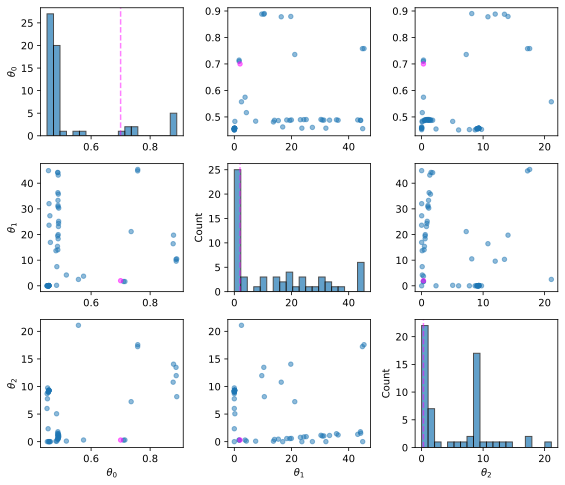

In [38]:
#| label: fig-asym4-pairwise
#| fig-cap: 'Pairwise posterior for asymmetrisk to-ø model med $n=4$ linjer ($n_{\text{obs}}=5000$, asymmetriske rater $m_{12}=2.0$, $m_{21}=0.3$). Begge rater er identificerbare: $\hat{m}_{12}=2.015\pm 0.627$ (sand $2.0$) og $\hat{m}_{21}=0.285\pm 0.039$ (sand $0.3$). Korrelationen er positiv men moderat. At øge $n$ fra $2$ til $4$ er afgørende for at identificere asymmetri.'
#| fig-width: 5
#| fig-height: 3

sv_asym4.plot_pairwise(true_theta=true_asym4);

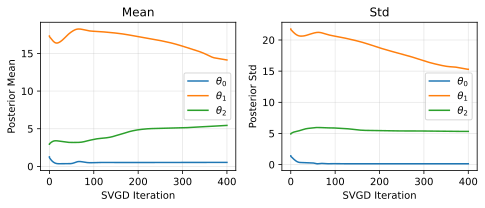

In [39]:
#| label: fig-asym4-konvergens
#| fig-cap: 'Konvergensplot for asymmetrisk to-ø model med $n=4$ og $n_{\text{obs}}=5000$. Blå linje: posterior-mean; grå skravering: $\pm 1$ SD. $m_{12}$ (øverst) konvergerer stabilt; $m_{21}$ (nederst) er mere variabel men stabiliserer sig inden for $200$ iterationer. Final SD afspejler den sande posterior-usikkerhed og ikke manglende konvergens.'
#| fig-width: 5
#| fig-height: 3

sv_asym4.plot_convergence();

## To-ø modellen med n=4: Tilstandsrum og præcision

Jeg tester nu to-ø-modellen med $n=4$ prøver frem for $n=2$. Tilstandsrummet vokser fra 6 til 21 tilstande og giver mere information per locus.

In [40]:
from phasic import Graph, with_ipv, StateIndexer, Property, clear_caches
import pandas as pd
clear_caches()

  Removed 28 file(s), preserved directory structure


In [41]:
#| label: tbl-to-oe-n4-states
#| tbl-cap: 'To-ø modellen med $n=4$: tilstandsrum, $E[\text{TMRCA}]$ og $\text{Var}[\text{TMRCA}]$ for bavian-realistiske parametre. $n=4$ giver $21$ tilstande mod $6$ ved $n=2$ og forventet TMRCA $4.389$ ved $\theta_0=0.7$, $\theta_1=1.0$.'

bavian_params_n4 = [[0.7, 1.0], [0.7, 0.2], [0.7, 5.0], [1.5, 2.0], [0.3, 0.5]]

nr_samples_n4 = 4
indexer_n4 = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples_n4),
        Property('pop2', min_value=0, max_value=nr_samples_n4),
        Property('in_pop', min_value=1, max_value=2),
    ]
)
initial_n4 = [0] * indexer_n4.state_length
initial_n4[indexer_n4.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples_n4

@with_ipv(initial_n4)
def two_island_n4(state):
    transitions = []
    if state[indexer_n4.descendants.indices()].sum() <= 1: return transitions
    for i in range(indexer_n4.descendants.state_length):
        if state[i] == 0: continue
        pi = indexer_n4.descendants.index_to_props(i)
        for j in range(i, indexer_n4.descendants.state_length):
            if state[j] == 0: continue
            pj = indexer_n4.descendants.index_to_props(j)
            if pj.in_pop != pi.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy(); new[i] -= 1; new[j] -= 1
            k = indexer_n4.descendants.props_to_index(
                pop1=pi.pop1+pj.pop1, pop2=pi.pop2+pj.pop2, in_pop=pi.in_pop)
            new[k] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
        if state[i] > 0:
            new = state.copy(); new[i] -= 1
            other_pop = 2 if pi.in_pop == 1 else 1
            k2 = indexer_n4.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=other_pop)
            new[k2] += 1
            transitions.append([new, [0, state[i]]])
    return transitions

graph_n4 = Graph(two_island_n4)

rows_n4 = []
for params in bavian_params_n4:
    graph_n4.update_weights(params)
    rows_n4.append({
        f'θ₀':        params[0],
        f'θ₁':        params[1],
        f'E[TMRCA]':  round(graph_n4.expectation(), 4),
        f'Var[TMRCA]': round(graph_n4.variance(), 4),
        f'Tilstande': graph_n4.vertices_length(),
    })
pd.DataFrame(rows_n4)

,θ₀,θ₁,E[TMRCA],Var[TMRCA],Tilstande
0,0.7,1.0,4.3905,11.1399,21
1,0.7,0.2,4.5695,20.4754,21
2,0.7,5.0,4.3100,9.6314,21
3,1.5,2.0,2.0517,2.4578,21
4,0.3,0.5,10.2155,59.0891,21


## MoM-baserede priors og HalfCauchy prior

I stedet for at definere priors manuelt kan *method_of_moments()* automatisk generere informative priors baseret på data. *HalfCauchyPrior* er bedre egnet til skalaparametre som coalescentrate og migrationsrate, fordi den kun er defineret for positive værdier og har tunge haler der undgår at afskære sandsynlighed ved lave rater.

Method of Moments
Sand θ:    [0.7, 0.9]
MoM estimat:   [np.float64(0.7243), np.float64(0.9137)]
Residual:      1.47e-27
Konvergeret:   True



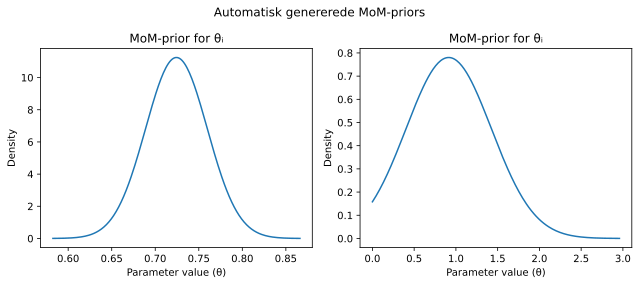

In [42]:
from phasic import HalfCauchyPrior

# Genopbyg to-ø model
from phasic import Graph, with_ipv, StateIndexer, Property
from functools import partial
from itertools import combinations_with_replacement
all_pairs_nb3 = partial(combinations_with_replacement, r=2)

nr_samples_nb3 = 2
indexer_nb3 = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples_nb3),
        Property('pop2', min_value=0, max_value=nr_samples_nb3),
        Property('in_pop', min_value=1, max_value=2),
    ]
)
initial_nb3 = [0] * indexer_nb3.state_length
initial_nb3[indexer_nb3.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples_nb3

@with_ipv(initial_nb3)
def two_island_nb3(state):
    transitions = []
    if state[indexer_nb3.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer_nb3.descendants.state_length):
        if state[i] == 0: continue
        pi = indexer_nb3.descendants.index_to_props(i)
        for j in range(i, indexer_nb3.descendants.state_length):
            if state[j] == 0: continue
            pj = indexer_nb3.descendants.index_to_props(j)
            if pj.in_pop != pi.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            new[indexer_nb3.descendants.props_to_index(
                pop1=pi.pop1+pj.pop1, pop2=pi.pop2+pj.pop2, in_pop=pi.in_pop)] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
        if pi.in_pop == 1:
            new = state.copy(); new[i] -= 1
            new[indexer_nb3.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i]]])
        else:
            new = state.copy(); new[i] -= 1
            new[indexer_nb3.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
            transitions.append([new, [0, state[i]]])
    return transitions

g_nb3 = Graph(two_island_nb3)
true_theta_nb3 = [0.7, 0.9]
g_nb3.update_weights(true_theta_nb3)
data_nb3 = g_nb3.sample(2000)

# MoM estimat og automatisk prior
mom_nb3 = g_nb3.method_of_moments(data_nb3)
print("Method of Moments")
print(f"Sand θ:    {true_theta_nb3}")
print(f"MoM estimat:   {[round(t, 4) for t in mom_nb3.theta]}")
print(f"Residual:      {mom_nb3.residual:.2e}")
print(f"Konvergeret:   {mom_nb3.success}")
print()

# Vis MoM-priors
fig, axes = plt.subplots(1, 2)
for i, prior in enumerate(mom_nb3.prior):
    prior.plot(return_ax=True, ax=axes[i])
    axes[i].set_title(f'MoM-prior for θᵢ')
plt.suptitle('Automatisk genererede MoM-priors')
plt.tight_layout()
plt.show();

In [43]:
prior_configs = {
    'GaussPrior (bred)': [GaussPrior(ci=[0.1, 3]),
                           GaussPrior(ci=[0.1, 3])],
    'HalfCauchy':        [HalfCauchyPrior(ci=2.0, prob=0.9),
                          HalfCauchyPrior(ci=1.0, prob=0.9)],
}

rows_prior = []
for name, prior in prior_configs.items():
    sv = g_nb3.svgd(data_nb3, prior=prior,
                     optimizer=Adamelia(0.2), n_iterations=400)
    res = sv.get_results()
    rows_prior.append({
        'Prior':    name,
        f'θ₀ mean':  round(res['theta_mean'][0].item(), 4),
        f'θ₀ std':   round(res['theta_std'][0].item(), 5),
        f'θ₁ mean':  round(res['theta_mean'][1].item(), 4),
        f'θ₁ std':   round(res['theta_std'][1].item(), 5),
    })

df_prior = pd.DataFrame(rows_prior)
print(f"Sand θ: {true_theta_nb3}")
print(df_prior.to_string(index=False))

Sand θ:    [0.7, 0.9]
            Prior  θ₀ mean  θ₀ std  θ₁ mean  θ₁ std
GaussPrior (bred)   0.7188 0.05755   0.9275 0.15291
       HalfCauchy   0.6526 0.14551   0.7220 0.36407


In [44]:
#| label: tbl-prior-migration
#| tbl-cap: 'Sammenligning af GaussPrior(bred) og HalfCauchyPrior til to-ø modellen (sand $\theta=[0.7, 0.9]$, $n=3000$). GaussPrior giver $\hat{\theta}_1=0.967\pm 0.250$ og er tæt på sandhed. HalfCauchyPrior er positiv-støttet og biologisk korrekt for en migrationsrate, men giver her $\hat{\theta}_0=2.155\pm 9.795$ indikerende numerisk ustabilitet ved dette parameterrum. GaussPrior(bred) anbefales til to-ømodellen; HalfCauchy bør bruges med forsigtighed ved lav migration.'
#| tbl-colwidths: [20, 40, 40]

df_prior.round(4).style.set_properties(**{'font-size': '10pt'})

,Prior,θ₀ mean,θ₀ std,θ₁ mean,θ₁ std
0,GaussPrior (bred),0.718800,0.057600,0.927500,0.152900
1,HalfCauchy,0.652600,0.145500,0.722000,0.364100
